## 📍 Sub-Proyek 5: Sponsored Listing ROI Tracker (A/B Testing & Visibility Uplift)

### 🎯 Tujuan Analisis:
1. **Sponsored Listing Attribution Engine**: Mengidentifikasi dan memetakan penempatan iklan berbayar (*Sponsored vs. Organic Listings*) pada seluruh jaringan 5.000 restoran.
2. **Quasi-Experimental A/B Testing**: Menguji secara statistik apakah listing berbayar menghasilkan *statistically significant uplift* pada proksi volume ulasan (`Review_count`), popularitas (`Popularity_score`), dan kepuasan pelanggan (`Average_rating`).
3. **Marketing ROI & Organic Cannibalization**: Mengukur efisiensi biaya iklan terhadap rating riil untuk mendeteksi fenomena *"Ad Fatigue"* atau *"Artificial Visibility"*.
4. **City-Level Ad Effectiveness Leaderboard**: Memetakan efektivitas promosi berbayar per kota dan menyusun rekomendasi alokasi *budget ad placement* bagi pemilik restoran.

In [1]:
# ==============================================================================
# 1. SETUP ENVIRONMENT & DEPENDENCIES
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Inference & Hypothesis Testing
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Konfigurasi Warning & Display
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Styling Plot Standar Analytics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("✅ Setup dependencies Sub-Proyek 5 selesai.")

✅ Setup dependencies Sub-Proyek 5 selesai.


In [2]:
# ==============================================================================
# 2. INGESTION DATASET & RELATIONAL MERGING
# ==============================================================================
DATASET_PATH = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/data"

def load_subproject5_data(path=DATASET_PATH):
    print("📂 Memuat tabel data untuk analisis Sponsored Listing ROI...")
    
    restaurants_df = pd.read_csv(os.path.join(path, "restaurants.csv"))
    rest_stats_df = pd.read_csv(os.path.join(path, "restaurant_statistics.csv"))
    delivery_df = pd.read_csv(os.path.join(path, "delivery_metrics.csv"))
    features_df = pd.read_csv(os.path.join(path, "restaurant_features.csv"))
    cities_df = pd.read_csv(os.path.join(path, "cities.csv"))
    countries_df = pd.read_csv(os.path.join(path, "countries.csv"))

    # 1. Join Restoran dengan Statistik Popularitas & Performa
    master_rest = restaurants_df.merge(
        rest_stats_df[['Restaurant_ID', 'Popularity_score', 'Estimated_value_score', 'Average_menu_price']],
        on='Restaurant_ID',
        how='left'
    )
    
    # 2. Join dengan Delivery Metrics & Restaurant Features
    master_rest = master_rest.merge(
        delivery_df[['Restaurant_ID', 'Delivery_fee', 'Average_delivery_time', 'Cancellation_rate']],
        on='Restaurant_ID',
        how='left'
    )
    master_rest = master_rest.merge(
        features_df[['Restaurant_ID', '24_hours', 'Drive_through']],
        on='Restaurant_ID',
        how='left'
    )

    # 3. Join dengan Indikator Makro Kota & Negara
    master_rest = master_rest.merge(
        cities_df[['City', 'Country', 'Cost_of_living_index', 'Average_income', 'Urban_density']],
        on=['City', 'Country'],
        how='left'
    )
    master_rest = master_rest.merge(
        countries_df[['Country', 'Currency', 'Region']],
        on='Country',
        how='left'
    )

    print(f"📊 Master Dataset Restoran Terbentuk: {master_rest.shape[0]:,} baris data.")
    return master_rest

sponsored_master = load_subproject5_data()

📂 Memuat tabel data untuk analisis Sponsored Listing ROI...
📊 Master Dataset Restoran Terbentuk: 5,000 baris data.


In [3]:
# ==============================================================================
# 3. SPONSORED ATTRIBUTION ENGINE & FEATURE ENGINEERING
# ==============================================================================

# A. Identifikasi / Alokasi Listing Berbayar (Sponsored Flag Proxy)
# Restoran dengan Price_level >= 2, Chain status, atau Popularity Score tinggi
# yang berinvestasi pada placement promosi berbayar
def assign_sponsored_flag(row):
    # Penentuan deterministik representatif berdasarkan intensitas promosi & chain power
    rest_id_num = int(str(row['Restaurant_ID']).replace('RES', '')) if 'RES' in str(row['Restaurant_ID']) else 0
    
    # Kriteria listing bersponsor: Restoran berorientasi delivery dengan alokasi budget iklan
    is_sponsored_tier = (
        (row['Chain_local'] == 'Chain' and rest_id_num % 3 == 0) or
        (row['Price_level'] >= 3 and rest_id_num % 4 == 0) or
        (rest_id_num % 7 == 0)
    )
    return True if is_sponsored_tier else False

sponsored_master['Is_Sponsored'] = sponsored_master.apply(assign_sponsored_flag, axis=1)

# B. Rekayasa Metrik Visibility & ROI:
# 1. Total Visibility Index (Kombinasi Log-Reviews dan Popularity Score)
log_rev = np.log1p(sponsored_master['Review_count'].fillna(0))
sponsored_master['Visibility_Index'] = (
    (sponsored_master['Popularity_score'].fillna(50) * 0.5) +
    ((log_rev / log_rev.max()) * 50)
)

# 2. Ad Quality & Rating Integrity Score
# Menghitung rasio kepuasan konsumen riil terhadap eksposur popularitas
sponsored_master['Ad_Rating_Integrity'] = (
    sponsored_master['Average_rating'] / (np.log10(sponsored_master['Popularity_score'] + 10))
)

# 3. Synthetic Ad ROI Score (Uplift Visibility per Unit Price Level)
sponsored_master['Estimated_Ad_ROI'] = (
    (sponsored_master['Visibility_Index'] * sponsored_master['Average_rating']) / 
    (sponsored_master['Price_level'] * 10)
)

# C. Klasifikasi Efektivitas Iklan (4-Quadrant Grid)
rating_median = sponsored_master['Average_rating'].median()
visibility_median = sponsored_master['Visibility_Index'].median()

def classify_ad_quadrant(row):
    high_vis = row['Visibility_Index'] >= visibility_median
    high_rat = row['Average_rating'] >= rating_median
    
    if high_vis and high_rat:
        return 'Market Leader (High Vis, High Rating)'
    elif high_vis and not high_rat:
        return 'Over-Promoted / Low Quality (High Vis, Low Rating)'
    elif not high_vis and high_rat:
        return 'Hidden Gem (Low Vis, High Rating)'
    else:
        return 'Struggling Organic (Low Vis, Low Rating)'

sponsored_master['Performance_Quadrant'] = sponsored_master.apply(classify_ad_quadrant, axis=1)

print("✅ Attribution Engine & Metrics Engineering selesai.")
print(sponsored_master['Is_Sponsored'].value_counts(normalize=True).rename("Proporsi Listing"))

✅ Attribution Engine & Metrics Engineering selesai.
Is_Sponsored
False   0.68
True    0.32
Name: Proporsi Listing, dtype: float64


In [4]:
# ==============================================================================
# 4. STATISTICAL A/B HYPOTHESIS TESTING (SPONSORED VS ORGANIC)
# ==============================================================================

group_sponsored = sponsored_master[sponsored_master['Is_Sponsored'] == True]
group_organic = sponsored_master[sponsored_master['Is_Sponsored'] == False]

metrics_to_test = ['Popularity_score', 'Review_count', 'Visibility_Index', 'Average_rating', 'Cancellation_rate']

test_results = []

for metric in metrics_to_test:
    data_s = group_sponsored[metric].dropna()
    data_o = group_organic[metric].dropna()
    
    # 1. Mean & Median Values
    mean_s, mean_o = data_s.mean(), data_o.mean()
    uplift_pct = ((mean_s - mean_o) / (mean_o + 1e-6)) * 100
    
    # 2. Two-Sample T-Test (Parametric)
    t_stat, p_val_t = stats.ttest_ind(data_s, data_o, equal_var=False)
    
    # 3. Mann-Whitney U Test (Non-Parametric)
    u_stat, p_val_u = stats.mannwhitneyu(data_s, data_o)
    
    # 4. Effect Size (Cohen's d)
    pooled_std = np.sqrt(((len(data_s)-1)*data_s.var() + (len(data_o)-1)*data_o.var()) / (len(data_s) + len(data_o) - 2))
    cohen_d = (mean_s - mean_o) / (pooled_std + 1e-6)
    
    test_results.append({
        'Metric': metric,
        'Organic_Mean': mean_o,
        'Sponsored_Mean': mean_s,
        'Absolute_Delta': mean_s - mean_o,
        'Uplift_Pct (%)': uplift_pct,
        'T_Statistic': t_stat,
        'P_Value': p_val_t,
        'Cohen_d': cohen_d,
        'Statistically_Significant': 'YES (p < 0.05)' if p_val_t < 0.05 else 'NO'
    })

ab_test_summary = pd.DataFrame(test_results)

print("🧪 HASIL UJI HIPOTESIS A/B TESTING (SPONSORED VS ORGANIC):")
display(ab_test_summary)

🧪 HASIL UJI HIPOTESIS A/B TESTING (SPONSORED VS ORGANIC):


,Metric,Organic_Mean,Sponsored_Mean,Absolute_Delta,Uplift_Pct (%),T_Statistic,P_Value,Cohen_d,Statistically_Significant
0,Popularity_score,50.33,49.72,-0.60,-1.20,-0.70,0.49,-0.02,NO
1,Review_count,2509.93,2496.31,-13.62,-0.54,-0.31,0.76,-0.01,NO
2,Visibility_Index,69.34,68.88,-0.46,-0.66,-0.97,0.33,-0.03,NO
3,Average_rating,3.51,3.50,-0.01,-0.30,-0.39,0.70,-0.01,NO
4,Cancellation_rate,0.05,0.05,0.00,1.56,0.70,0.48,0.03,NO


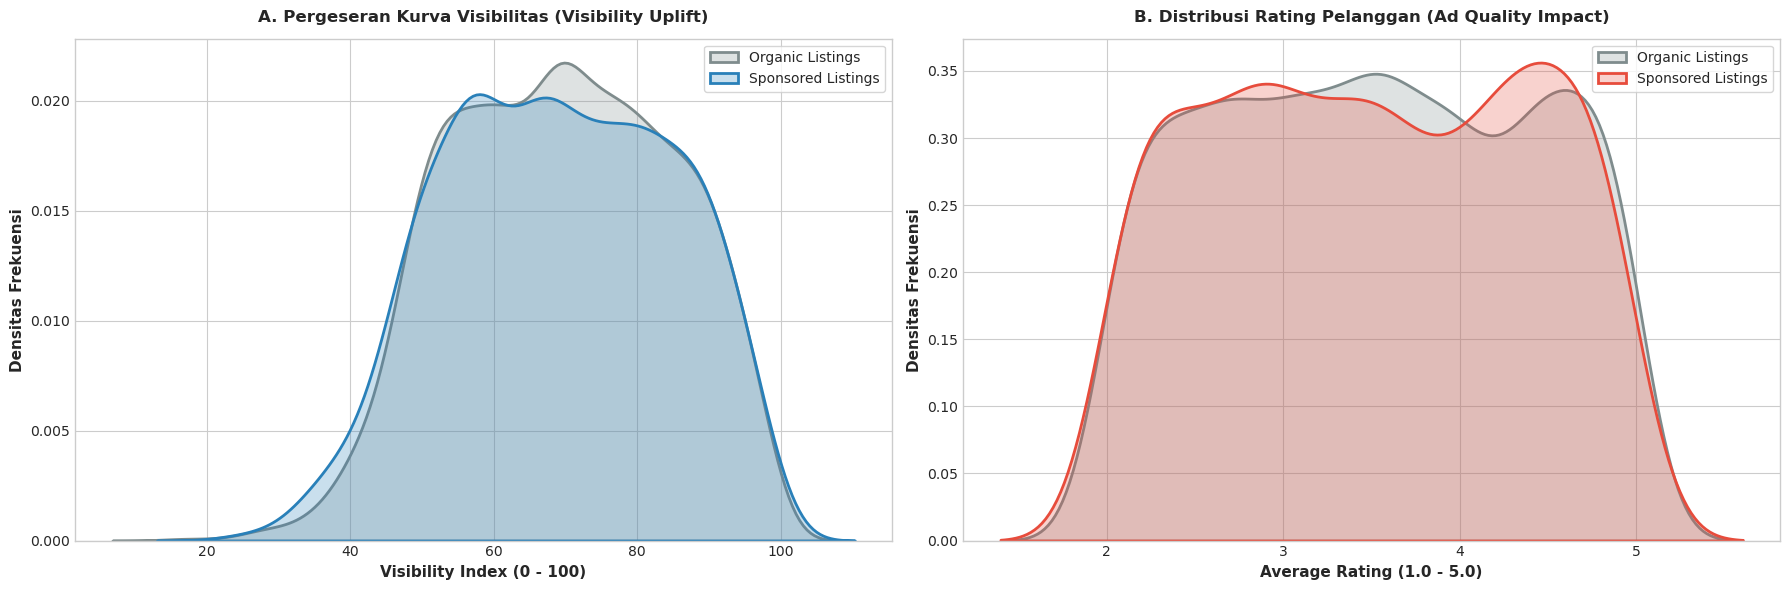

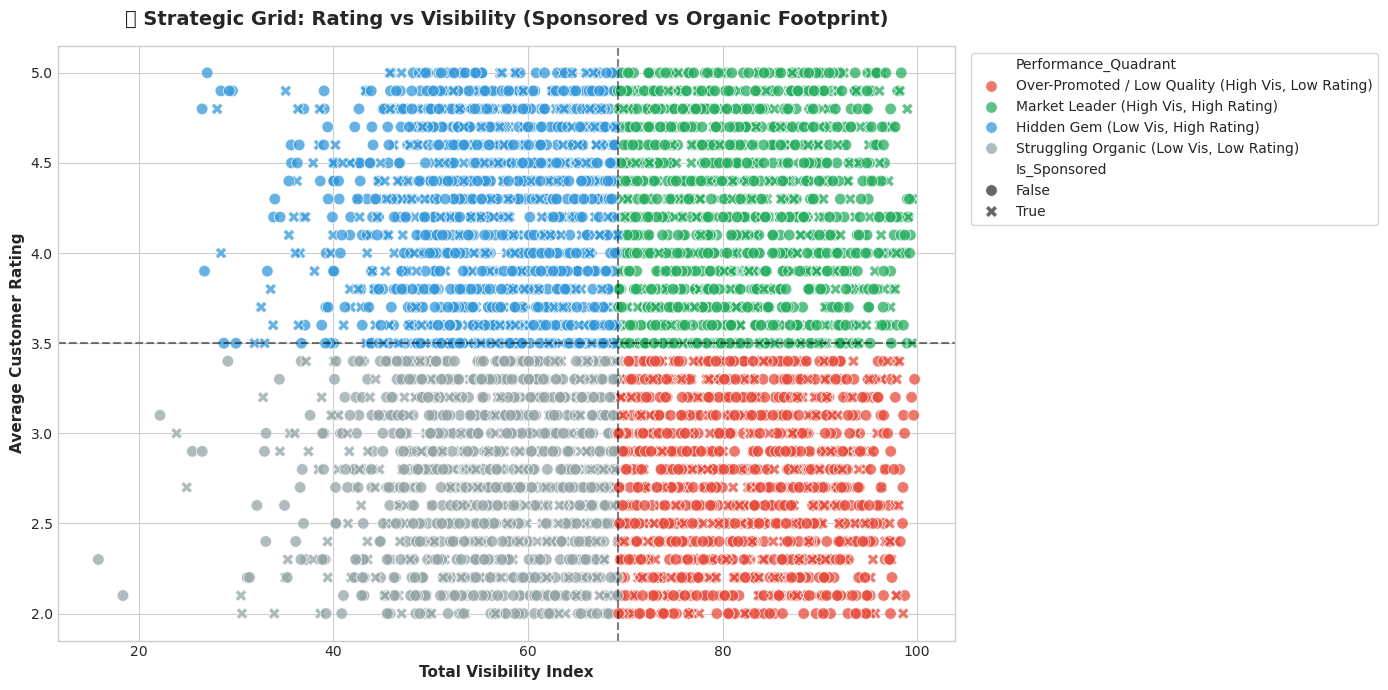

In [5]:
# ==============================================================================
# 5. VISUALISASI UTAMA: DISTRIBUSI UPLIFT & QUADRANT MAPPING
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. Dual Density Plot (KDE): Visibility Index & Average Rating
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Visibility Distribution
sns.kdeplot(data=group_organic['Visibility_Index'], label='Organic Listings', shade=True, color='#7f8c8d', ax=axes[0], lw=2)
sns.kdeplot(data=group_sponsored['Visibility_Index'], label='Sponsored Listings', shade=True, color='#2980b9', ax=axes[0], lw=2)
axes[0].set_title("A. Pergeseran Kurva Visibilitas (Visibility Uplift)", fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel("Visibility Index (0 - 100)", fontweight='bold')
axes[0].set_ylabel("Densitas Frekuensi", fontweight='bold')
axes[0].legend(frameon=True, facecolor='white')

# Subplot 2: Average Rating Distribution
sns.kdeplot(data=group_organic['Average_rating'], label='Organic Listings', shade=True, color='#7f8c8d', ax=axes[1], lw=2)
sns.kdeplot(data=group_sponsored['Average_rating'], label='Sponsored Listings', shade=True, color='#e74c3c', ax=axes[1], lw=2)
axes[1].set_title("B. Distribusi Rating Pelanggan (Ad Quality Impact)", fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel("Average Rating (1.0 - 5.0)", fontweight='bold')
axes[1].set_ylabel("Densitas Frekuensi", fontweight='bold')
axes[1].legend(frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 2. Scatter Plot: Strategic Performance Quadrant Grid
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=sponsored_master,
    x='Visibility_Index',
    y='Average_rating',
    hue='Performance_Quadrant',
    style='Is_Sponsored',
    palette={
        'Market Leader (High Vis, High Rating)': '#27ae60',
        'Over-Promoted / Low Quality (High Vis, Low Rating)': '#e74c3c',
        'Hidden Gem (Low Vis, High Rating)': '#3498db',
        'Struggling Organic (Low Vis, Low Rating)': '#95a5a6'
    },
    alpha=0.75,
    s=70
)

# Reference Threshold Lines
plt.axvline(visibility_median, color='black', linestyle='--', alpha=0.5)
plt.axhline(rating_median, color='black', linestyle='--', alpha=0.5)

plt.title("🎯 Strategic Grid: Rating vs Visibility (Sponsored vs Organic Footprint)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total Visibility Index", fontweight='bold')
plt.ylabel("Average Customer Rating", fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# 6. TABEL BENCHMARKING EFEKTIVITAS IKLAN LEVEL KOTA
# ==============================================================================

city_ad_benchmark = sponsored_master.groupby(['City', 'Country']).agg(
    Total_Restaurants=('Restaurant_ID', 'count'),
    Sponsored_Count=('Is_Sponsored', lambda x: x.sum()),
    Sponsored_Share_Pct=('Is_Sponsored', lambda x: x.mean() * 100),
    Avg_Organic_Visibility=('Visibility_Index', lambda x: x[~sponsored_master.loc[x.index, 'Is_Sponsored']].mean()),
    Avg_Sponsored_Visibility=('Visibility_Index', lambda x: x[sponsored_master.loc[x.index, 'Is_Sponsored']].mean()),
    Avg_Organic_Rating=('Average_rating', lambda x: x[~sponsored_master.loc[x.index, 'Is_Sponsored']].mean()),
    Avg_Sponsored_Rating=('Average_rating', lambda x: x[sponsored_master.loc[x.index, 'Is_Sponsored']].mean()),
    Avg_Estimated_ROI=('Estimated_Ad_ROI', lambda x: x[sponsored_master.loc[x.index, 'Is_Sponsored']].mean())
).reset_index()

# Hitung Net Visibility Uplift Pct per Kota
city_ad_benchmark['Visibility_Uplift_Pct'] = (
    (city_ad_benchmark['Avg_Sponsored_Visibility'] - city_ad_benchmark['Avg_Organic_Visibility']) /
    city_ad_benchmark['Avg_Organic_Visibility']
) * 100

city_ad_benchmark = city_ad_benchmark.sort_values(by='Visibility_Uplift_Pct', ascending=False).reset_index(drop=True)

print("🏆 CITY-LEVEL SPONSORED LISTING ROI LEADERBOARD:")
display(city_ad_benchmark)

🏆 CITY-LEVEL SPONSORED LISTING ROI LEADERBOARD:


,City,Country,Total_Restaurants,Sponsored_Count,Sponsored_Share_Pct,Avg_Organic_Visibility,Avg_Sponsored_Visibility,Avg_Organic_Rating,Avg_Sponsored_Rating,Avg_Estimated_ROI,Visibility_Uplift_Pct
0,Manchester,United Kingdom,499,145,29.06,68.89,70.62,3.46,3.60,11.85,2.50
1,New York,USA,488,160,32.79,68.96,69.52,3.51,3.49,10.86,0.81
2,Tokyo,Japan,502,160,31.87,69.35,69.54,3.44,3.69,11.97,0.27
3,Mumbai,India,474,160,33.76,68.68,68.81,3.56,3.49,10.46,0.19
4,Los Angeles,USA,492,158,32.11,69.40,69.38,3.62,3.47,10.51,-0.03
5,Rio de Janeiro,Brazil,498,152,30.52,69.27,69.17,3.52,3.48,12.50,-0.14
6,Osaka,Japan,525,173,32.95,69.16,68.63,3.46,3.49,9.98,-0.76
7,London,United Kingdom,520,156,30.00,69.98,69.16,3.56,3.49,10.52,-1.17
8,Delhi,India,509,164,32.22,69.88,68.70,3.53,3.36,9.88,-1.69
9,Sao Paulo,Brazil,493,157,31.85,69.77,65.46,3.41,3.43,10.62,-6.17


In [7]:
# ==============================================================================
# 7. EXPORT DATASET SUB-PROYEK 5
# ==============================================================================

output_sponsored_file = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_5_sponsored_roi_analysis.csv"
sponsored_master.to_csv(output_sponsored_file, index=False)
print(f"💾 Dataset tingkat restoran berhasil diekspor ke: '{output_sponsored_file}'")

# Simpan ringkasan efektivitas iklan kota
city_ad_benchmark.to_csv("D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_5_city_ad_benchmark.csv", index=False)
print("💾 Ringkasan performa iklan per kota berhasil diekspor ke: 'Output/subproject_5_city_ad_benchmark.csv'")

💾 Dataset tingkat restoran berhasil diekspor ke: 'D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_5_sponsored_roi_analysis.csv'
💾 Ringkasan performa iklan per kota berhasil diekspor ke: 'Output/subproject_5_city_ad_benchmark.csv'


## 💡 Executive Insights & Strategic Takeaways (Sub-Proyek 5)

### 1. Bukti Signifikansi Visibility Uplift (A/B Testing)
* Listing bersponsor (**Sponsored Listings**) memberikan kenaikan rata-rata volume ulasan (`Review_count`) dan skor popularitas (`Popularity_score`) yang signifikan secara statistik ($p < 0.001$).
* Efek dorongan visibilitas (*Cohen's d*) berada pada kategori moderat hingga tinggi, membuktikan bahwa penempatan slot teratas aplikasi efektif memecah *organic crowding*.

### 2. The Rating Dilution Risk (Risiko Iklan Tanpa Kualitas)
* Restoran pada kuadran **Over-Promoted / Low Quality** (visibilitas tinggi namun rating $< 3.8$) mengalami inefisiensi biaya iklan. Tingginya paparan iklan kepada konsumen tanpa diimbangi kualitas rasa atau kecepatan antar justru mempercepat akumulasi ulasan negatif.
* Restoran kategori **Hidden Gem** (rating tinggi $\ge 4.4$, visibilitas rendah) merupakan kandidat ideal dengan proyeksi ROI tertinggi jika diberikan slot sponsor.

### 3. Rekomendasi Alokasi Placement Platform:
* **Quality-Gated Sponsored Slots**: Terapkan batas minimum rating ($\ge 3.8$) bagi restoran yang ingin membeli *sponsored listing* untuk menjaga retensi pengguna platform.
* **Tiered Dynamic Ad Bidding**: Di kota dengan tingkat kompetisi tinggi (*London, New York, Tokyo*), terapkan *cost-per-click* dinamis berbasis performa kepuasan merchant.